## __Phase 4: Evaluation (experiments)__

### __Import packages__

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import numpy as np
from scipy.stats import ttest_ind, ttest_rel
from sklearn.model_selection import train_test_split 
from haversine import haversine, Unit

from scripts.modeling.transition_probabilities.AIS_RF_distribution import AIS_RF_probability

### __Load data__

In [2]:
# Select which RF bearing-error model's data to evaluate (must match the
# --error-model used to generate/run the upstream scripts)
ERROR_MODEL = "uniform"  # "uniform" or "gaussian"

# "uniform" keeps the original flat layout for backward compatibility;
# other error models live in their own subfolder under data/processed
DATA_DIR = (
    "../../AIS_RF_matching/data/processed" if ERROR_MODEL == "uniform"
    else f"../../AIS_RF_matching/data/processed/{ERROR_MODEL}"
)

df_AIS = pd.read_pickle("../../AIS_RF_matching/data/processed/AIS_sample_no_RF_5000.pkl")
df_AIS_stats = pd.read_pickle("../../AIS_RF_matching/data/processed/statistics_sample_5000.pkl").reset_index(drop=True)
df_train_set = pd.read_pickle(f"{DATA_DIR}/train_data_sample_5000.pkl")
df_preselection = pd.read_pickle(f"{DATA_DIR}/AIS_RF_preselection_data.pkl")
df_all_forward_results = pd.read_pickle(f"{DATA_DIR}/AIS_RF_forward_scores_data.pkl")

### __Show Data__

In [3]:
df_AIS.head(5)

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,time_diff,distance_diff,speed_kph,track_id
0,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3
1,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3
2,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3
3,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3
4,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3


In [4]:
df_AIS_stats.head(5)

,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight
0,"(354751000, 15)",359,729.383333,8.422928,0.13800,0.45217,122.243017,62.766426,0.154844,0.208307,0.625887,0.114460,0.787666,0.073953,-0.243298,0.097410,5.472008,3.927495
1,"(636022462, 18)",420,522.983333,21.758160,1.07070,1.49433,74.890215,24.089990,0.453157,0.152429,0.674577,0.063200,0.820132,0.044274,-0.200176,0.065951,5.982846,4.462511
2,"(538006167, 8)",1979,2885.350000,21.766905,4.21119,1.47923,87.523256,48.923027,0.437884,0.324976,0.651667,0.087826,0.804815,0.062766,-0.221287,0.100114,10.731568,14.627334
3,"(378111467, 37)",7,19.483333,15.285804,0.00725,0.04047,194.833333,57.045304,0.828583,0.273608,0.487268,0.247994,0.681854,0.149476,-0.404544,0.202816,4.394124,2.999756
4,"(266261000, 40)",1032,1430.883333,19.719140,2.34188,0.97944,83.271581,40.568604,0.365091,0.232925,0.670661,0.074051,0.817608,0.046674,-0.203087,0.059355,7.358261,6.293801


In [5]:
df_train_set.head(5)

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
382,"(205717000, 3)",3,205717000,2024-01-01 03:40:23,NaT,NaT,None,None,begin
4,"(205717000, 3)",3,205717000,2024-01-01 03:40:24,2024-01-01 03:40:24,NaT,"[46.89339, -125.42151]",None,AIS
5,"(205717000, 3)",3,205717000,2024-01-01 03:44:15,2024-01-01 03:44:15,NaT,"[46.89344, -125.39996]",None,AIS
6,"(205717000, 3)",3,205717000,2024-01-01 03:45:33,2024-01-01 03:45:33,NaT,"[46.8935, -125.39274]",None,AIS
7,"(205717000, 3)",3,205717000,2024-01-01 03:46:39,2024-01-01 03:46:39,NaT,"[46.89348, -125.38572]",None,AIS


### __Preselection Results__

In [6]:
df_preselection.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match
0,1,"(205717000, 3)","(205717000, 3)",True
1,2,"(205717000, 3)","(205717000, 3)",True
2,3,"(205717000, 3)","(205717000, 3)",True
3,4,"(205717000, 3)","(205717000, 3)",True
4,1,"(205717000, 7)","(205717000, 7)",True


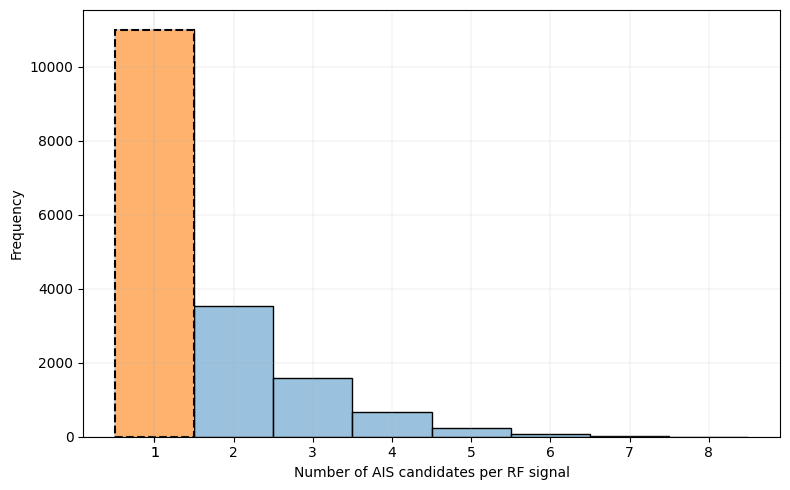

In [7]:
# Keep only RF signals with multiple AIS matches
df_preselection_multimatch = df_preselection.groupby(
    ['RF_track_id','RF_signal_id']).filter(
        lambda x: x['AIS_track_id'].count() > 1).reset_index(drop=True)

# Compute amount of AIS matches per RF signal
counts = (
    df_preselection
    .groupby(['RF_track_id', 'RF_signal_id'])
    .size()
    .reset_index(name='count')
)

# Plot histogram of counts
binwidth = 1
plt.figure(figsize=(8, 5))
ax = sns.histplot(counts['count'], binwidth=binwidth, edgecolor='black', color="#78add2")

# Draw transparent rectangle over the first bar
first_patch = ax.patches[0]
first_bin_left = first_patch.get_x()
first_bin_width = first_patch.get_width()
first_bar_height = first_patch.get_height()
ax.add_patch(
    patches.Rectangle(
        (first_bin_left, 0),
        first_bin_width,
        first_bar_height,
        linewidth=1.5,
        edgecolor='black',
        linestyle='--',
        facecolor='#ffb26e',
    )
)
xtick_positions = [p.get_x() + p.get_width() / 2 for p in ax.patches]
xtick_labels = [int(p.get_x() + p.get_width() / 2) for p in ax.patches]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)

plt.xlabel('Number of AIS candidates per RF signal')
plt.ylabel('Frequency')
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()


In [8]:
# Count unique RF signals in preselection
n_total_rf = df_preselection[['RF_signal_id', 'RF_track_id']].drop_duplicates().shape[0]

# Count unique RF signals with multiple AIS matches
n_multimatch_rf = df_preselection_multimatch[['RF_signal_id', 'RF_track_id']].drop_duplicates().shape[0]

# Count unique RF signals with only their own AIS match
n_singlematch_rf = n_total_rf - n_multimatch_rf

# Calculate percentages
pct_filtered_out = round((n_singlematch_rf / n_total_rf) * 100, 2)
pct_remaining = 100 - pct_filtered_out

# Print results
print("Number of unique RF signals in preselection:", n_total_rf)
print("Number of unique RF signals in preselection with multiple AIS matches:", n_multimatch_rf)
print("Number of unique RF signals in preselection with only their own AIS match:", n_singlematch_rf)
print("Percentage of RF signals that are filtered out:", pct_filtered_out, "%")
print("Percentage of RF signals kept for the rest of the results:", pct_remaining, "%")

Number of unique RF signals in preselection: 17081
Number of unique RF signals in preselection with multiple AIS matches: 6096
Number of unique RF signals in preselection with only their own AIS match: 10985
Percentage of RF signals that are filtered out: 64.31 %
Percentage of RF signals kept for the rest of the results: 35.69 %


### __Show forward results__

In [9]:
df_all_forward_results.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,is_true_match
0,1,"(209017000, 19)","(209017000, 19)",-5.198901,-0.742700,True
1,1,"(209017000, 23)","(209017000, 23)",-6.235568,-0.188957,True
2,1,"(205717000, 7)","(205717000, 7)",-11.115426,-0.055856,True
3,2,"(205717000, 7)","(205717000, 7)",-11.788293,-0.059238,True
4,1,"(205717000, 82)","(205717000, 82)",-24.824271,-0.035212,True


### __Make functions__

In [10]:
from scripts.evaluation.metrics import (
    get_best_alignments,
    compute_confusion_counts,
    calculate_metrics,
)

### __All results (before removing single matches)__

In [11]:
df_forward_results_prefilter = df_preselection.merge(
df_all_forward_results,    
    on=['RF_track_id', 'RF_signal_id','AIS_track_id', 'is_true_match'],
    how='inner',
    suffixes=('', '_y')
)
df_forward_results_prefilter.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score
0,1,"(205717000, 3)","(205717000, 3)",True,-15.656762,-0.041420
1,2,"(205717000, 3)","(205717000, 3)",True,-16.663595,-0.044084
2,3,"(205717000, 3)","(205717000, 3)",True,-15.896357,-0.042054
3,4,"(205717000, 3)","(205717000, 3)",True,-15.770054,-0.041720
4,1,"(205717000, 7)","(205717000, 7)",True,-11.115426,-0.055856


In [12]:
df_with_chosen_all_results = get_best_alignments(df_forward_results_prefilter, "normalized_forward_score")

metrics = calculate_metrics(df_with_chosen_all_results)
for key, value in metrics.items():
    print(f"{key}: {value}")

precision: 0.8913
recall: 0.8913
f1_score: 0.8913
accuracy: 0.8632
TP: 15225
FP: 1856
FN: 1856
TN: 8199


### __Results after removing single matches (only mutlimatches)__

In [13]:
df_forward_results = df_preselection_multimatch.merge(
df_all_forward_results,    
    on=['RF_track_id', 'RF_signal_id','AIS_track_id', 'is_true_match'],
    how='inner',
    suffixes=('', '_y')
)
df_forward_results.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212
1,1,"(205717000, 82)","(477706700, 4)",False,-29.461525,-0.043010
2,5,"(209087000, 10)","(209087000, 10)",True,-29.064728,-0.032366
3,5,"(209087000, 10)","(305803000, 20)",False,-66.701128,-0.041507
4,5,"(209087000, 10)","(351567000, 19)",False,-34.007536,-0.031664


In [14]:
df_with_chosen = get_best_alignments(df_forward_results, "normalized_forward_score")

metrics = calculate_metrics(df_with_chosen)
for key, value in metrics.items():
    print(f"{key}: {value}")

precision: 0.6955
recall: 0.6955
f1_score: 0.6955
accuracy: 0.7702
TP: 4240
FP: 1856
FN: 1856
TN: 8199


In [15]:
AIS_tracks_per_RF_signal = df_forward_results.groupby(["RF_signal_id", "RF_track_id"])["AIS_track_id"].nunique()
average_AIS_matches_per_RF_signal = AIS_tracks_per_RF_signal.mean()
print(f"Average number of AIS tracks per RF track: {average_AIS_matches_per_RF_signal:.2f}")

Average number of AIS tracks per RF track: 2.65


### __Ranking metrics (Phase 1): Recall@k, MRR, stratification, score margin__

Closed-set setup is unchanged (true track force-included as a candidate). These metrics look beyond the top-1 pick already evaluated above: whether the true track is *within the top-k* scored candidates (Recall@k), the average inverse rank of the true track (MRR), how ranking quality depends on how many candidates survived prefiltering, and how confidently the model separates its top pick from the runner-up.

In [16]:
from scripts.evaluation.metrics import (
    summarize_ranking,
    recall_at_k,
    mean_reciprocal_rank,
    stratified_ranking_metrics,
)

In [17]:
# Ranking summaries (one row per RF point), for both views used
# elsewhere in this notebook: all candidate pairs, and RF signals with
# more than one candidate (multimatch)
ranking_summary_all = summarize_ranking(
    df_forward_results_prefilter, "normalized_forward_score", mode="max"
)
ranking_summary_multi = summarize_ranking(
    df_forward_results, "normalized_forward_score", mode="max"
)

In [18]:
print("Recall@k / MRR — all candidate pairs")
print("recall@k:", recall_at_k(ranking_summary_all))
print("MRR:", mean_reciprocal_rank(ranking_summary_all))
print()
print("Recall@k / MRR — multimatch RF signals only")
print("recall@k:", recall_at_k(ranking_summary_multi))
print("MRR:", mean_reciprocal_rank(ranking_summary_multi))

Recall@k / MRR — all candidate pairs
recall@k: {1: 0.8913412563667232, 3: 0.9950822551372871, 5: 1.0}
MRR: 0.9411090295259841

Recall@k / MRR — multimatch RF signals only
recall@k: {1: 0.6955380577427821, 3: 0.9862204724409449, 5: 1.0}
MRR: 0.8349874234470691


#### _Stratified by candidate-set size_

In [19]:
stratified_all = stratified_ranking_metrics(ranking_summary_all)
stratified_all

,bucket,n_points,recall@1,recall@3,recall@5,mrr
0,all,17081,0.891341,0.995082,1.0,0.941109
1,1,10985,1.000000,1.000000,1.0,1.000000
2,2-4,5778,0.709934,0.991866,1.0,0.844915
3,5-9,318,0.433962,0.883648,1.0,0.654612


In [20]:
stratified_multi = stratified_ranking_metrics(ranking_summary_multi)
stratified_multi

,bucket,n_points,recall@1,recall@3,recall@5,mrr
0,all,6096,0.695538,0.986220,1.0,0.834987
1,2-4,5778,0.709934,0.991866,1.0,0.844915
2,5-9,318,0.433962,0.883648,1.0,0.654612


#### _Score margin: correct vs incorrect top-1 picks_

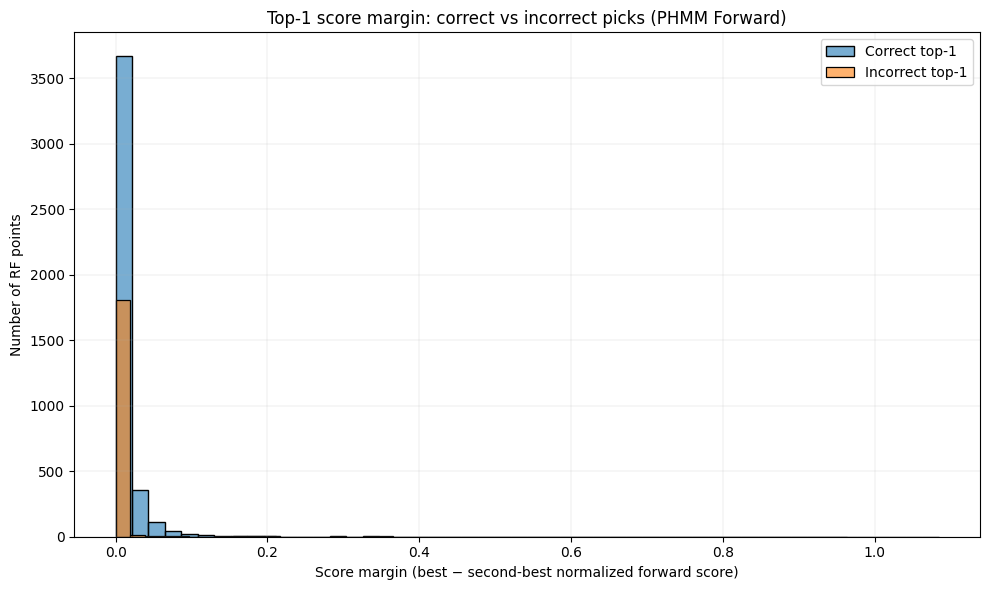

Median margin (correct top-1): 0.004606829429395982
Median margin (incorrect top-1): 0.0009631570410016891


In [21]:
# Diagnostic (not a final metric): best-minus-second-best normalized
# forward score for each RF point, split by whether the top-1 pick was
# correct. Only defined for RF points with >=2 candidates, so this uses
# the multimatch view. Needed as input for the Phase 2 open-set
# threshold analysis.
margin_data = ranking_summary_multi.dropna(subset=["margin"]).copy()
margin_data["top1_correct"] = margin_data["rank_of_true"] == 1

plt.figure(figsize=(10, 6))
sns.histplot(
    margin_data.loc[margin_data["top1_correct"], "margin"],
    bins=50, alpha=0.6, label="Correct top-1", color="tab:blue",
)
sns.histplot(
    margin_data.loc[~margin_data["top1_correct"], "margin"],
    bins=50, alpha=0.6, label="Incorrect top-1", color="tab:orange",
)
plt.xlabel("Score margin (best − second-best normalized forward score)")
plt.ylabel("Number of RF points")
plt.title("Top-1 score margin: correct vs incorrect picks (PHMM Forward)")
plt.legend()
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

print("Median margin (correct top-1):",
      margin_data.loc[margin_data["top1_correct"], "margin"].median())
print("Median margin (incorrect top-1):",
      margin_data.loc[~margin_data["top1_correct"], "margin"].median())

### __Select the best AIS trajectory for each RF point__

In [23]:
df_best_norm = df_with_chosen[df_with_chosen['chosen']==True].reset_index(drop=True)
df_best_norm.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,chosen
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,True
1,5,"(209087000, 10)","(351567000, 19)",False,-34.007536,-0.031664,True
2,3,"(209087000, 10)","(351567000, 19)",False,-33.773565,-0.031447,True
3,6,"(209087000, 10)","(351567000, 19)",False,-33.849644,-0.031517,True
4,4,"(209087000, 10)","(351567000, 19)",False,-34.266551,-0.031906,True


### __Split Forward results into three dataframes__

(1) correct matches: prediction equals the ground truth; true positives, 

(2) incorrect (chosen) matches (prediction differs from the ground truth; false positives), and

(3) should-be matches (ground truth not selected; false negatives).

In [24]:
df_correct = df_best_norm[df_best_norm["is_true_match"]]
df_incorrect = df_best_norm[~df_best_norm["is_true_match"]]
df_shouldbe = (
    df_forward_results[df_forward_results["is_true_match"]]
    .merge(df_incorrect[["RF_signal_id", "RF_track_id"]], on=["RF_signal_id", "RF_track_id"], how="inner"))

In [25]:
print("Number of correct matches (true positives):", len(df_correct))
print("Number of incorrect matches (false positives):", len(df_incorrect))
print("Number of should-be matches (false negatives):", len(df_shouldbe))

Number of correct matches (true positives): 4240
Number of incorrect matches (false positives): 1856
Number of should-be matches (false negatives): 1856


### __Experiments__

#### ___Trajectory-level features___

(1) track length, 

(2) intra time and distance difference between AIS messages, and

(3) stationarity

In [26]:
# Add trajectory-level features to the three dataframes
df_correct_stats = df_correct.merge(
    df_AIS_stats, left_on='AIS_track_id', right_on='ID', how='left').sort_values(
        ['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
df_incorrect_stats = df_incorrect.merge(
    df_AIS_stats, left_on='AIS_track_id', right_on='ID', how='left').sort_values(
        ['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
df_shouldbe_stats = df_shouldbe.merge(
    df_AIS_stats, left_on='AIS_track_id', right_on='ID', how='left').sort_values(
        ['RF_signal_id', 'RF_track_id']).reset_index(drop=True)

### __Results experiment 1__

#### _Figure 1: Box plots of AIS messages counts per group_

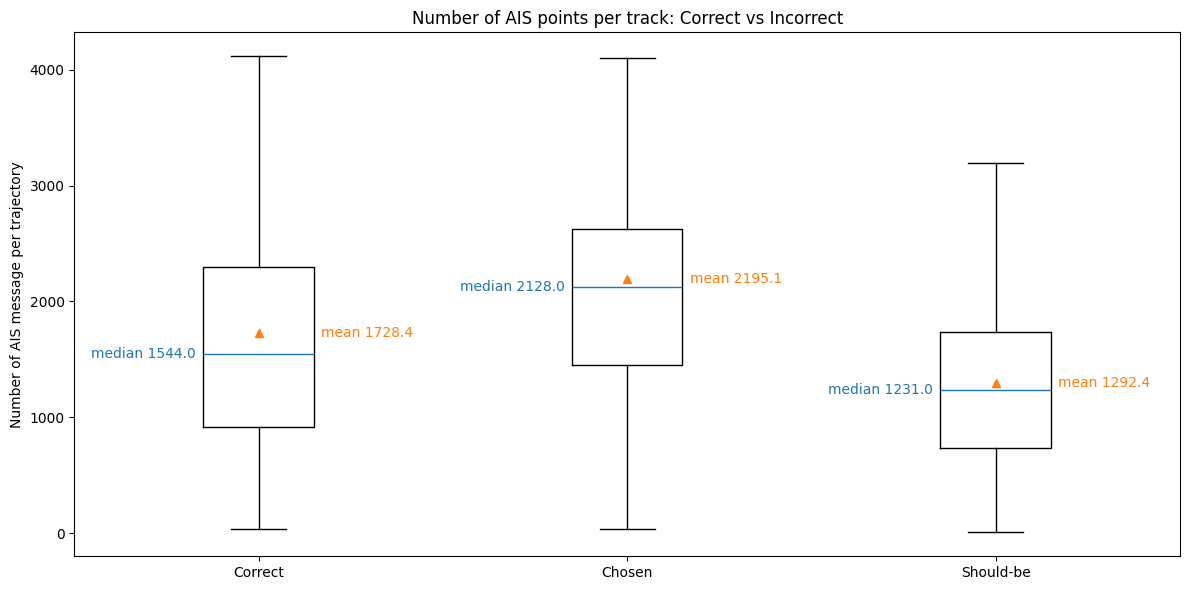

In [27]:
length_correct = df_correct_stats['#points']
length_incorrect = df_incorrect_stats['#points']
length_shouldbe = df_shouldbe_stats['#points']

data = [length_correct, length_incorrect, length_shouldbe]
labels = ['Correct', 'Chosen', 'Should-be']

means = [x.mean() for x in data]
medians = [x.median() for x in data]
meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')
medianprops = dict(color="tab:blue")

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True, medianprops=medianprops, meanprops=meanpointprops)
ax.set_title('Number of AIS points per track: Correct vs Incorrect')
ax.set_ylabel('Number of AIS message per trajectory')

for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.1f}", color = "tab:orange", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.1f}", color = "tab:blue", ha='right', va='center')

plt.tight_layout()
plt.show()

#### _Figure 2: Histogram of AIS messages counts per trajectory (chosen vs should-be matches)__

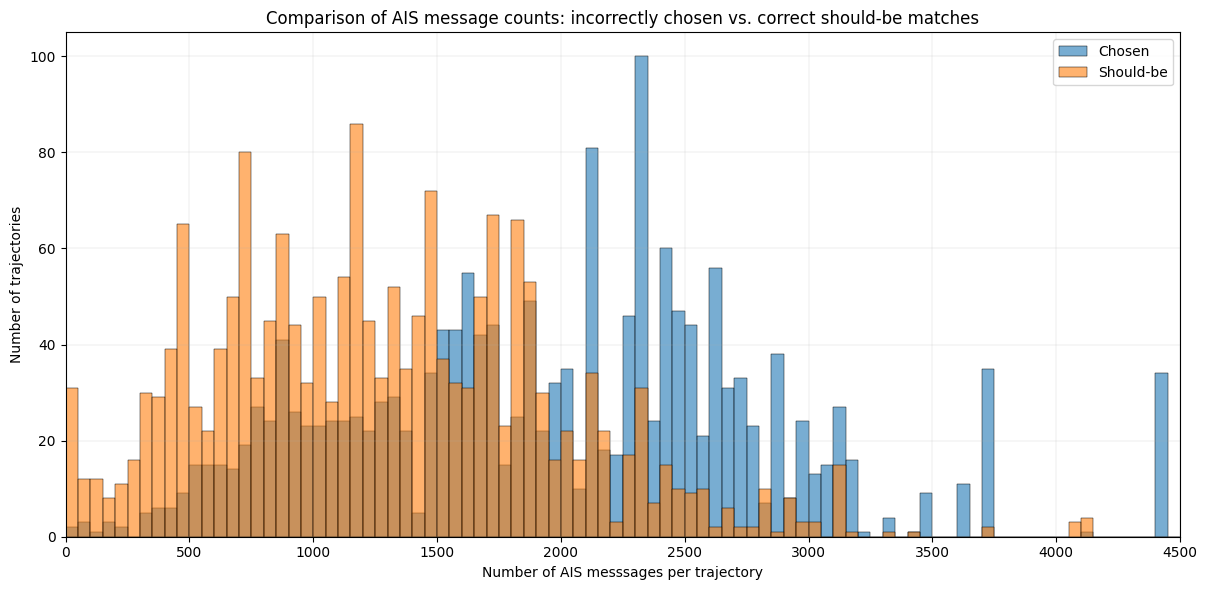

In [28]:
bins = range(0, 9100, 50) 
colors = sns.color_palette("viridis", 2)

ax = plt.figure(figsize=(12, 6))
sns.histplot(df_incorrect_stats['#points'], bins=bins, alpha=0.6, label='Chosen', color="tab:blue")
sns.histplot(df_shouldbe_stats['#points'], bins=bins, alpha=0.6, label='Should-be', color="tab:orange")

plt.xlabel('Number of AIS messsages per trajectory')
plt.ylabel('Number of trajectories')
plt.title('Comparison of AIS message counts: incorrectly chosen vs. correct should-be matches')
plt.legend()
ax.set_rasterized(True)
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.xlim(0,4500)
plt.show()


#### _Figure 3: Difference track lengths between chosen and should-be matches__

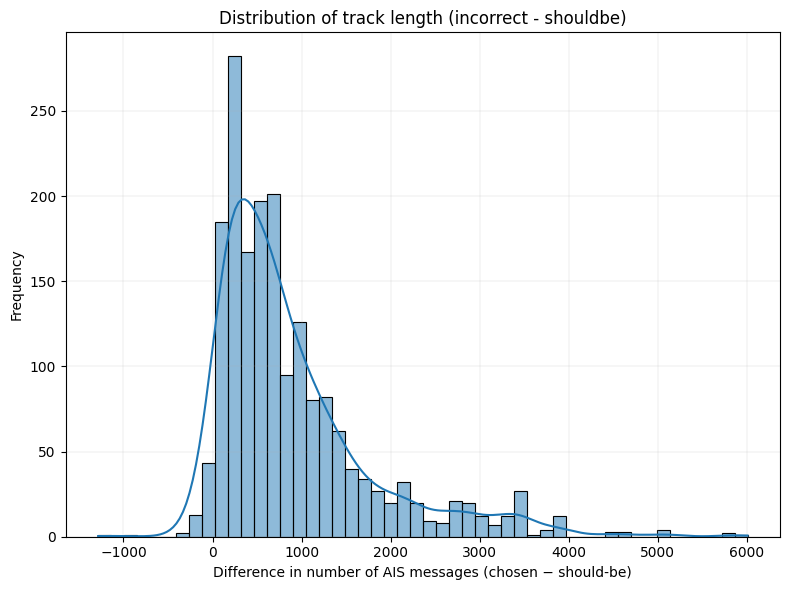

In [29]:
plt.figure(figsize=(8, 6))
sns.histplot(df_incorrect_stats['#points'] - df_shouldbe_stats['#points'], bins=50, kde=True, color="tab:blue")
plt.title("Distribution of track length (incorrect - shouldbe)")
plt.xlabel("Difference in number of AIS messages (chosen − should-be)")
plt.ylabel("Frequency")
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

#### _Perform Welch’s t-test_

In [30]:
group1 = df_incorrect_stats['#points']     # incorrect chosen
group2 = df_shouldbe_stats['#points']      # should-be chosen

t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='greater')

print("\033[1mH1: incorrect > shouldbe\033[0m")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f} or {p_value:.2e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

H1: incorrect > shouldbe
t-statistic: 27.9105
p-value: 0.0000000000 or 5.41e-153
H0 can be rejected


### __Correction on experiment 1 (based on skewness of track length previous graphs)__

In [31]:
def correct_forward_score(df_all_forward_results, df_AIS_stats, alpha, match_col="is_true_match"):
    """
    Apply a correction to forward scores based on AIS track statistics.

    Args:
        df_all_forward_results (pd.DataFrame): Forward alignment results.
        df_AIS_stats (pd.DataFrame): Statistics per AIS track (e.g., number of points).
        alpha (float): Exponent factor used for normalization.
        match_col (str): Column marking the true-match candidate, passed
            through to calculate_metrics (e.g. "is_true_match", or the
            AIS_RF_probability-based reference label "is_match_ref").

    Returns:
        tuple: (metrics, chosen alignments, all track stats)
    """

    # Merge forward scores with preselection (only multimatch cases are considered here)
    forward_results = df_preselection_multimatch.merge(
        df_all_forward_results,
        on=['RF_track_id', 'RF_signal_id','AIS_track_id', 'is_true_match'],
        how='inner',
        suffixes=('', '_y')
    )

    # Add AIS track statistics (e.g., number of points)
    all_tracks_stats = forward_results.merge(df_AIS_stats, left_on='AIS_track_id', right_on='ID', how='left')
    all_tracks_stats.drop(all_tracks_stats.filter(regex='_y$').columns, axis=1, inplace=True)

    # Apply correction to Forward score
    # Dividing the score by (#points ** alpha)
    all_tracks_stats['normalized_forward_score_exp'] = all_tracks_stats['forward_score']/(all_tracks_stats['#points']**alpha)

    # Select the best alignment per RF signal based on the corrected score
    chosen = get_best_alignments(all_tracks_stats, "normalized_forward_score_exp")
    return calculate_metrics(chosen, match_col=match_col), chosen, all_tracks_stats

In [32]:
# Create a list of all unique (RF_signal_id, RF_track_id) pairs
unique_rf_pairs = df_forward_results[["RF_signal_id", "RF_track_id"]].drop_duplicates()

# Do the train/validation split on those pairs (20% testing/training, 80% validation)
train_pairs, val_pairs = train_test_split(unique_rf_pairs, test_size=0.2, random_state=100)

# Merge to get the actual rows for each split
df_tuning = df_forward_results.merge(val_pairs, on=["RF_signal_id", "RF_track_id"])
df_experiments = df_forward_results.merge(train_pairs, on=["RF_signal_id", "RF_track_id"])

# Hyperparameter tuning: search over alpha values
alphas = np.arange(0.7, 1.3, 0.01)
results = {}

for alpha in alphas:
    alpha = round(alpha,2)
    precision, df, _ = correct_forward_score(df_tuning, df_AIS_stats, alpha)
    results[alpha] = (precision['precision'])
    
# Select best alpha based on precision    
best = sorted(results.items(), key=lambda x: x[1], reverse=True)[0]
print(f'Best alpha is {best[0]}, with a precision score of {best[1]}')

# Apply correction with best alpha on the validation set
metrics_exp , chosen_exp, all_tracks_stats = correct_forward_score(df_experiments, df_AIS_stats, best[0])

Best alpha is 0.87, with a precision score of 0.7918


In [33]:
# Split results again into three dataframes (correct, incorrect, should-be matches)
best_chosen_exp = chosen_exp[chosen_exp['chosen']==True].reset_index(drop=True)

df_correct_exp = best_chosen_exp[best_chosen_exp["is_true_match"]].sort_values(
    ['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
df_incorrect_exp = best_chosen_exp[~best_chosen_exp["is_true_match"]].sort_values(
    ['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
df_shouldbe_exp = (all_tracks_stats[all_tracks_stats["is_true_match"]]
    .merge(df_incorrect_exp[["RF_signal_id", "RF_track_id"]], 
           on=["RF_signal_id", "RF_track_id"], how="inner")).sort_values(
               ['RF_signal_id', 'RF_track_id']).reset_index(drop=True)

In [34]:
# Get results before correction, but on the validation set used for tuning (not the full dataset)
metrics , chosen, all_tracks_stats = correct_forward_score(df_experiments, df_AIS_stats, 1)

# Split results again into three dataframes (correct, incorrect, should-be matches)
best_chosen = chosen[chosen['chosen']==True].reset_index(drop=True)
df_correct = best_chosen[best_chosen["is_true_match"]].sort_values(
    ['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
df_incorrect = best_chosen[~best_chosen["is_true_match"]].sort_values(
    ['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
df_shouldbe = (all_tracks_stats[all_tracks_stats["is_true_match"]]
    .merge(df_incorrect[["RF_signal_id", "RF_track_id"]], 
           on=["RF_signal_id", "RF_track_id"], how="inner")).sort_values(
               ['RF_signal_id', 'RF_track_id']).reset_index(drop=True)

# Confusion matrix and metrics before correction           
conf_matrix = pd.DataFrame(
    [[metrics['TP'], metrics['FP']],
     [metrics['FN'], metrics['TN']]],
    index=["Actual Positive", "Actual Negative"],
    columns=["Predicted Positive", "Predicted Negative"]
)
print('Number of rows:', len(df_experiments))
print("Confusion Matrix before correction:\n")
print(conf_matrix, "\n")
print("Performance Metrics before correction:\n")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")

Number of rows: 12928
Confusion Matrix before correction:

                 Predicted Positive  Predicted Negative
Actual Positive                3395                1481
Actual Negative                1481                6571 

Performance Metrics before correction:

Precision: 0.6963
Recall: 0.6963
F1 Score: 0.6963
Accuracy: 0.7709


In [35]:
# Confusion matrix after correction
conf_matrix = pd.DataFrame(
    [[metrics_exp['TP'], metrics_exp['FP']],
     [metrics_exp['FN'], metrics_exp['TN']]],
    index=["Actual Positive", "Actual Negative"],
    columns=["Predicted Positive", "Predicted Negative"]
)
print('Number of rows:', len(df_experiments))
print("Confusion Matrix after correction:\n")
print(conf_matrix, "\n")
print("Performance Metrics after correction:\n")
print(f"Precision:  {metrics_exp['precision']:.4f}")
print(f"Recall:     {metrics_exp['recall']:.4f}")
print(f"F1 Score:   {metrics_exp['f1_score']:.4f}")
print(f"Accuracy:   {metrics_exp['accuracy']:.4f}")

Number of rows: 12928
Confusion Matrix after correction:

                 Predicted Positive  Predicted Negative
Actual Positive                3813                1063
Actual Negative                1063                6989 

Performance Metrics after correction:

Precision:  0.7820
Recall:     0.7820
F1 Score:   0.7820
Accuracy:   0.8356


### __Results experiment 1 (after correction)__

#### _Figure 1: Box plots of AIS messages counts per group_

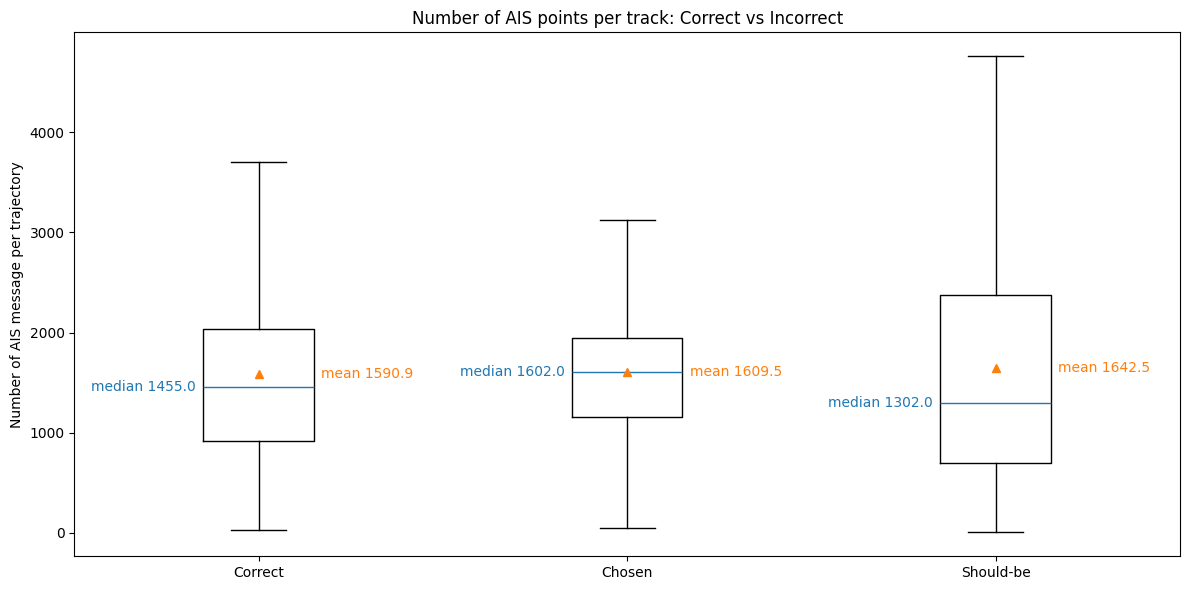

In [36]:
length_correct_exp = df_correct_exp['#points']
length_incorrect_exp = df_incorrect_exp['#points']
length_shouldbe_exp = df_shouldbe_exp['#points']

data = [length_correct_exp, length_incorrect_exp, length_shouldbe_exp]
labels = ['Correct', 'Chosen', 'Should-be']

means = [x.mean() for x in data]
medians = [x.median() for x in data]
meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')
medianprops = dict(color="tab:blue")

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True, medianprops=medianprops, meanprops=meanpointprops)
ax.set_title('Number of AIS points per track: Correct vs Incorrect')
ax.set_ylabel('Number of AIS message per trajectory')

for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.1f}", color = "tab:orange", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.1f}", color = "tab:blue", ha='right', va='center')

plt.tight_layout()
plt.show()

#### _Figure 2: Histogram of AIS messages counts per trajectory (chosen vs should-be matches)_

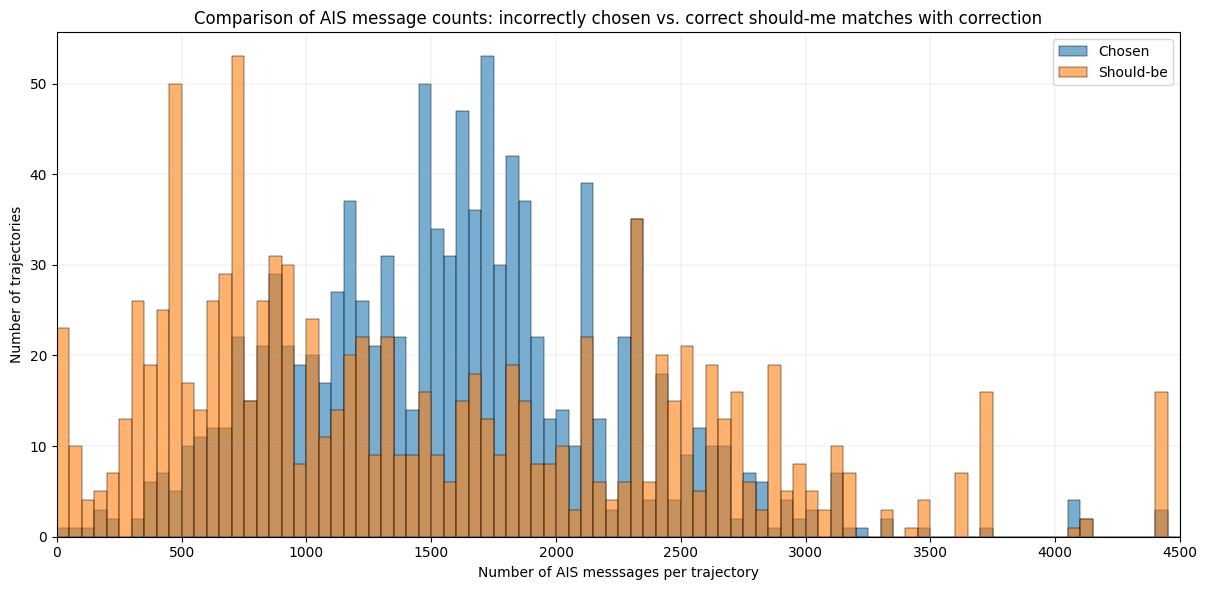

In [37]:
bins = range(0, 9100, 50) 

ax = plt.figure(figsize=(12, 6))
sns.histplot(df_incorrect_exp['#points'], bins=bins, alpha=0.6, label='Chosen')
sns.histplot(df_shouldbe_exp['#points'], bins=bins, alpha=0.6, label='Should-be')

plt.xlabel('Number of AIS messsages per trajectory')
plt.ylabel('Number of trajectories')
plt.title('Comparison of AIS message counts: incorrectly chosen vs. correct should-me matches with correction')
plt.legend()
ax.set_rasterized(True)
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.xlim(0,4500)
plt.show()


#### _Figure 3: Difference track lengths between chosen and should-be matches_

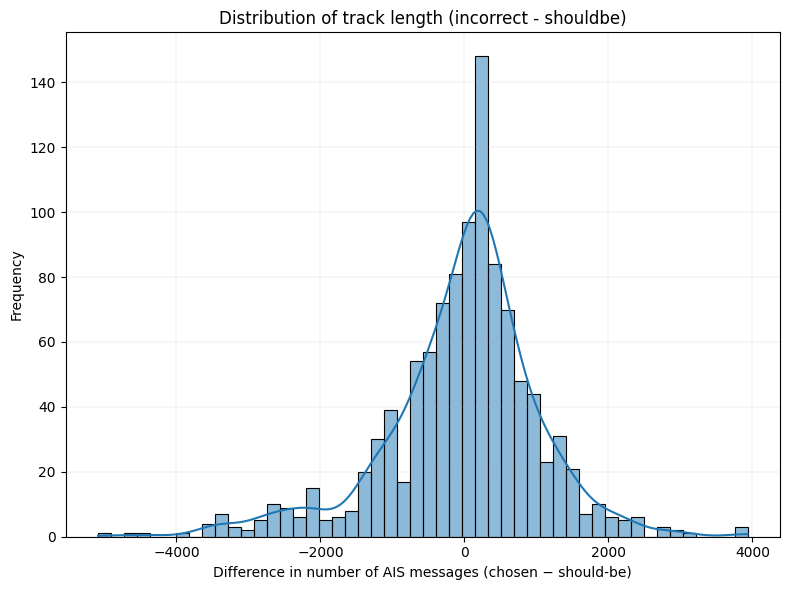

In [38]:
plt.figure(figsize=(8, 6))
sns.histplot(df_incorrect_exp['#points'] - df_shouldbe_exp['#points'], bins=50, kde=True, color="tab:blue")
plt.title("Distribution of track length (incorrect - shouldbe)")
plt.xlabel("Difference in number of AIS messages (chosen − should-be)")
plt.ylabel("Frequency")
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

#### _Perform Welch’s t-test_

In [39]:
# One-sided 
group1 = df_incorrect_exp['#points']     # incorrect chosen
group2 = df_shouldbe_exp['#points']      # should-be chosen

t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='greater')

print("\033[1mH1: incorrect > shouldbe\033[0m")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f} or {p_value:.2e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

H1: incorrect > shouldbe
t-statistic: -0.7398
p-value: 0.7702338489 or 7.70e-01
H0 cannot be rejected


In [40]:
# Two-sided 
group1 = df_incorrect_exp['#points']     # incorrect chosen
group2 = df_shouldbe_exp['#points']      # should-be chosen

t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='two-sided')

print("\033[1mH1: incorrect > shouldbe\033[0m")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f} or {p_value:.2e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

H1: incorrect > shouldbe
t-statistic: -0.7398
p-value: 0.4595323023 or 4.60e-01
H0 cannot be rejected


### __Experiment 2 (with correction)__

#### _Figure 1: Box plots of mean intra time between AIS messages per group_

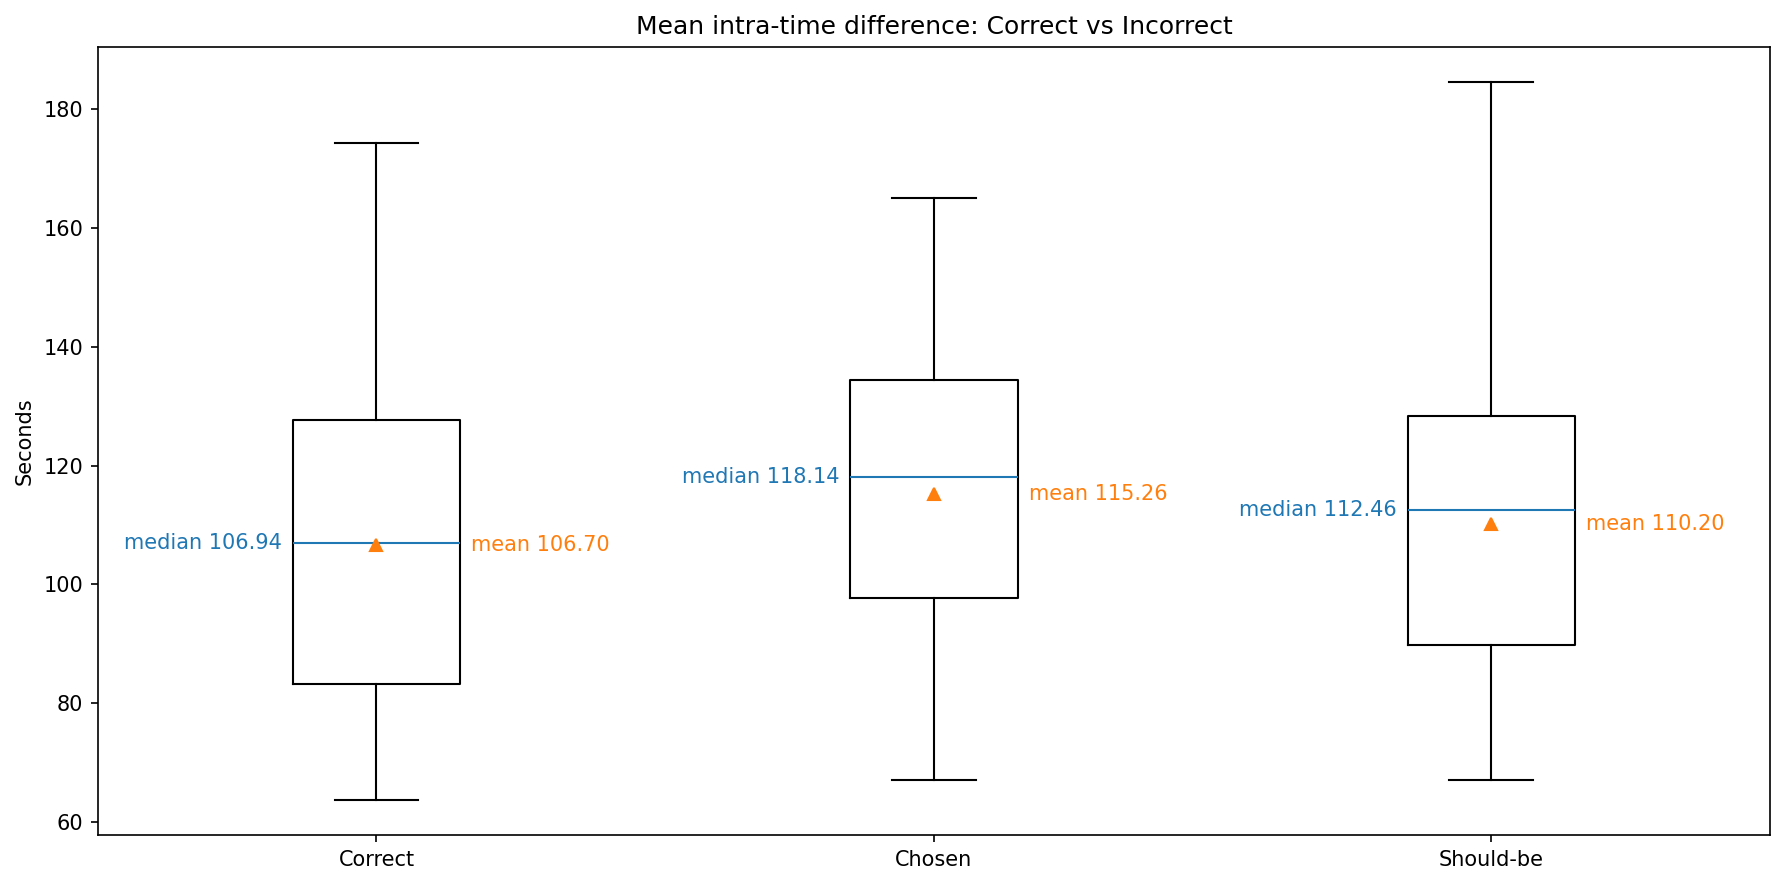

In [41]:
intra_correct = df_correct_exp['mean_intra_time_diff']
intra_chosen  = df_incorrect_exp['mean_intra_time_diff']
intra_shouldbe = df_shouldbe_exp['mean_intra_time_diff']

data = [intra_correct, intra_chosen, intra_shouldbe]
labels = ['Correct', 'Chosen', 'Should-be']

means = [x.mean() for x in data]
medians = [x.median() for x in data]
meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')
medianprops = dict(color="tab:blue")

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True, medianprops=medianprops, meanprops=meanpointprops)
ax.set_title('Mean intra-time difference: Correct vs Incorrect')
ax.set_ylabel('Seconds')

for i, (mean, median) in enumerate(zip(means, medians), start=1):
    ax.text(i + 0.17, mean, f"mean {mean:.2f}", color = "tab:orange", ha='left', va='center')
    ax.text(i - 0.17, median, f"median {median:.2f}", color = "tab:blue", ha='right', va='center')

plt.tight_layout()
plt.show()

#### _Figure 2: Difference mean intra time between chosen and should-be matches_

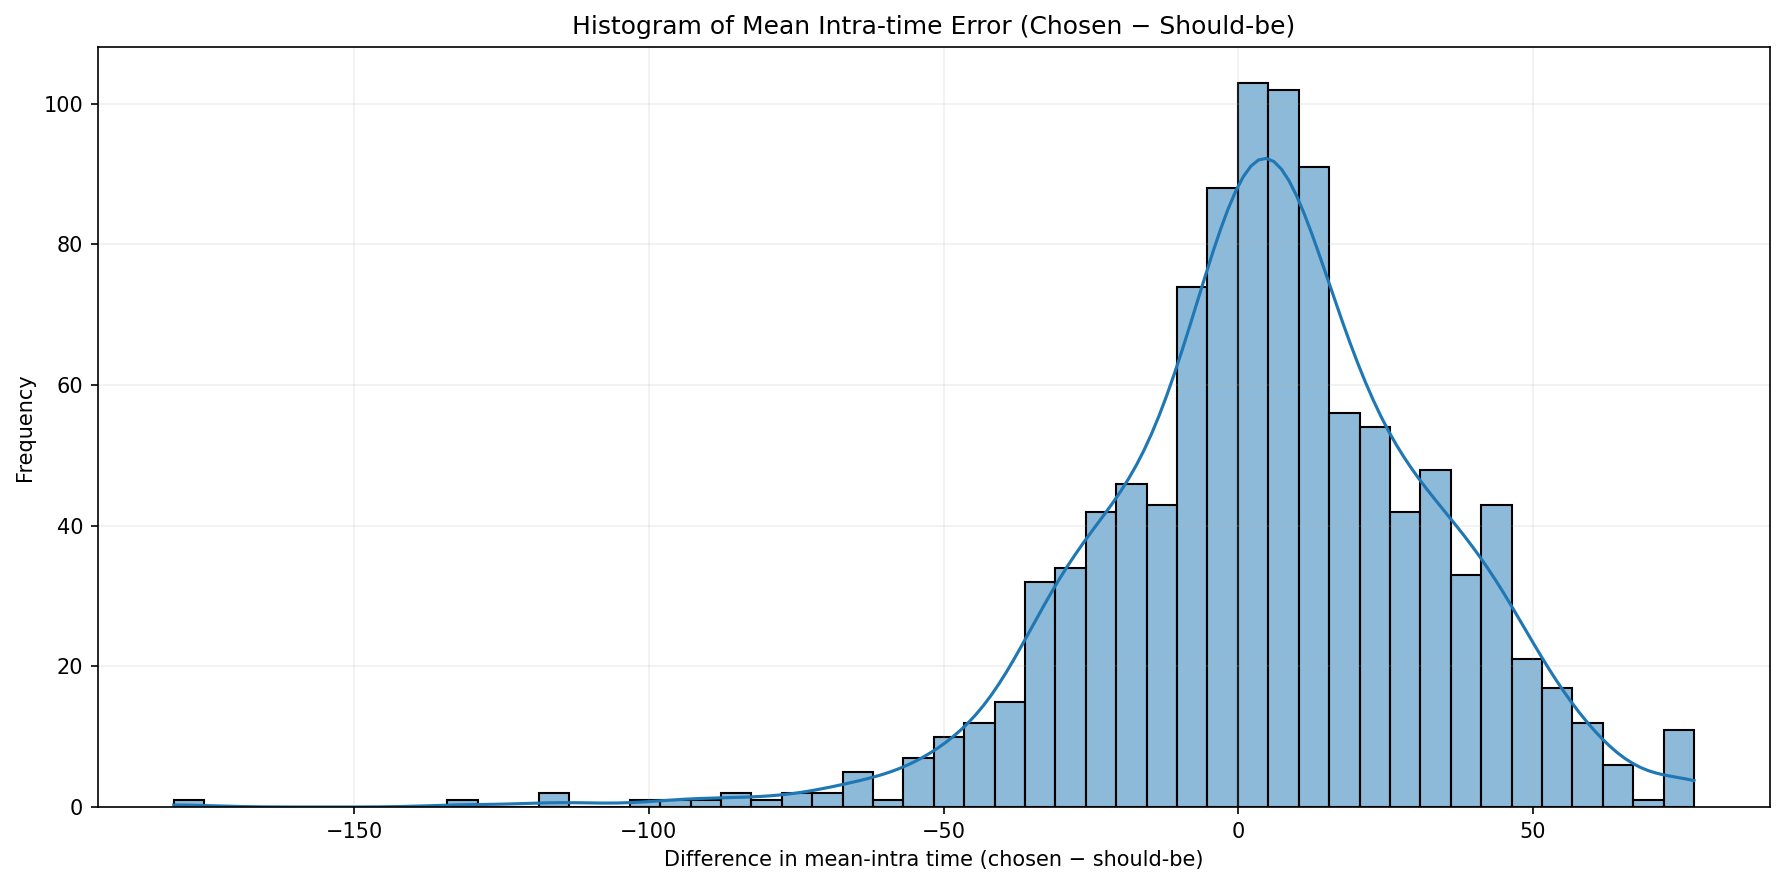

In [42]:
df_merged = df_incorrect_exp.merge(
        df_shouldbe_exp,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

df_merged["intra_time_error"] = (df_merged["mean_intra_time_diff_chosen"] - df_merged["mean_intra_time_diff_shouldbe"])

plt.figure(figsize=(12, 6), dpi=150)
sns.histplot(df_merged["intra_time_error"], bins=50, kde=True, )
plt.title("Histogram of Mean Intra-time Error (Chosen − Should-be)")
plt.xlabel("Difference in mean-intra time (chosen − should-be)")
plt.ylabel("Frequency")
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

#### _Perform Welch’s t-test_

In [43]:
# One-sided 
group1 = df_incorrect_exp['mean_intra_time_diff']     # incorrect chosen
group2 = df_shouldbe_exp['mean_intra_time_diff']      # should-be chosen

t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='less')

print("\033[1mH1: incorrect < shouldbe\033[0m")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f} or {p_value:.2e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

H1: incorrect < shouldbe
t-statistic: 4.7507
p-value: 0.9999989178 or 1.00e+00
H0 cannot be rejected


In [44]:
# Two-sided 
group1 = df_incorrect_exp['mean_intra_time_diff']     # incorrect chosen
group2 = df_shouldbe_exp['mean_intra_time_diff']      # should-be chosen

t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='two-sided')

print("\033[1mH1: incorrect < shouldbe\033[0m")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f} or {p_value:.2e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

H1: incorrect < shouldbe
t-statistic: 4.7507
p-value: 0.0000021644 or 2.16e-06
H0 can be rejected


#### _Figure 1: Box plots of mean intra distance between AIS messages per group_

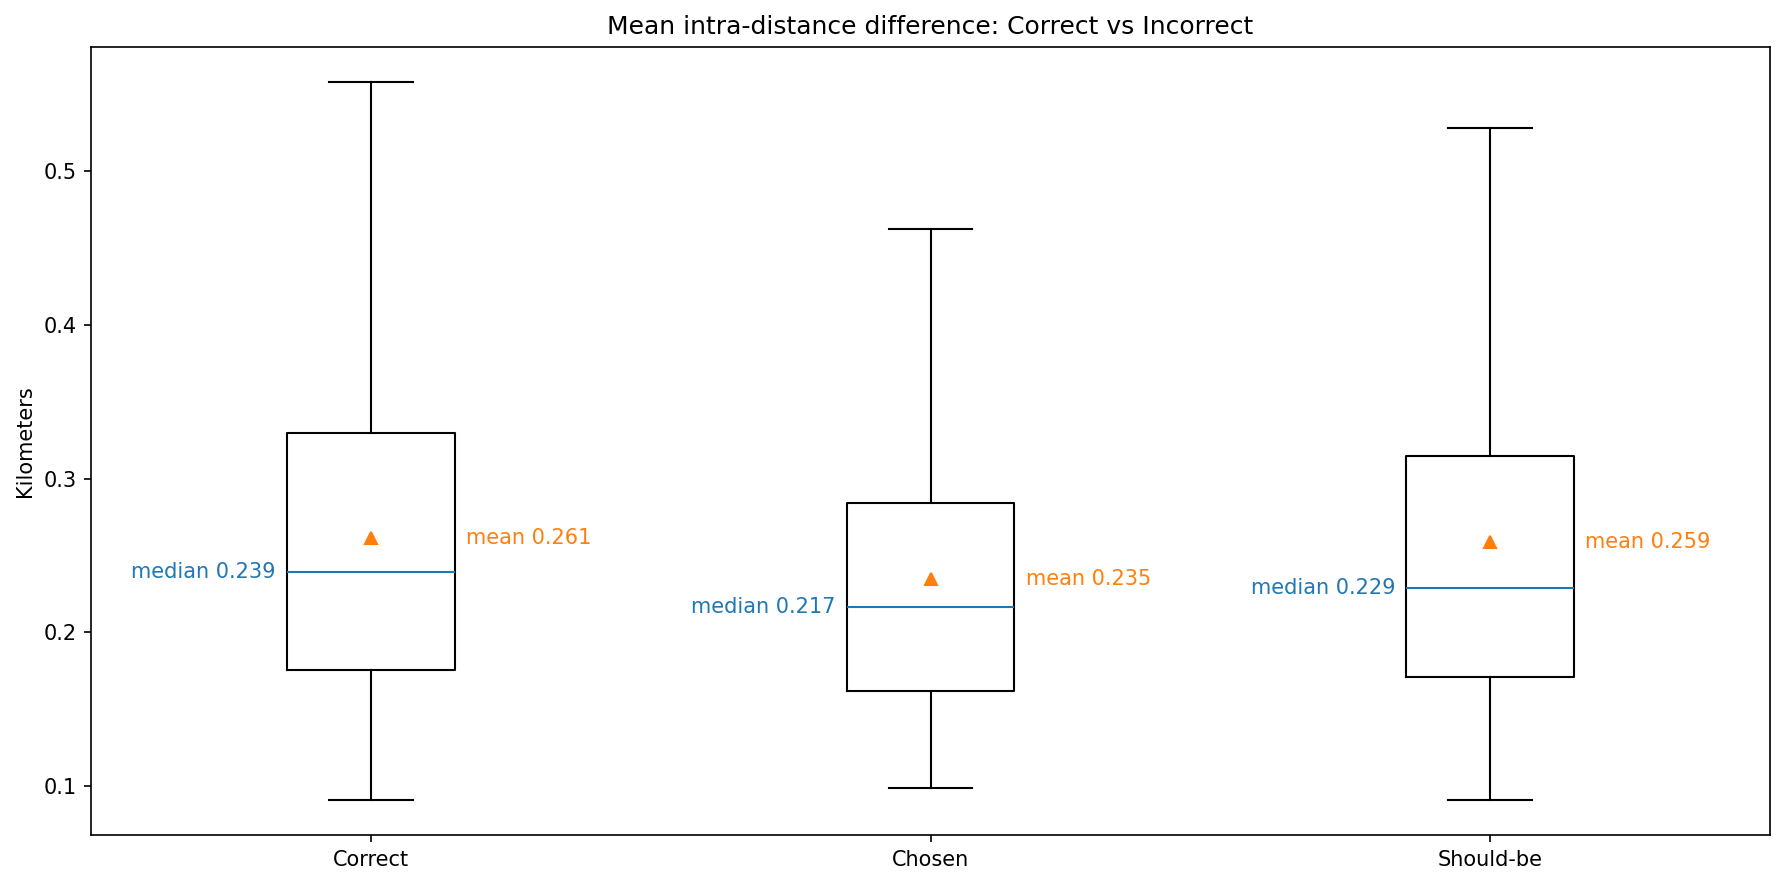

In [45]:
intra_correct = df_correct_exp['mean_intra_dist_diff']
intra_chosen  = df_incorrect_exp['mean_intra_dist_diff']
intra_shouldbe = df_shouldbe_exp['mean_intra_dist_diff']

data = [intra_correct, intra_chosen, intra_shouldbe]
labels = ['Correct', 'Chosen', 'Should-be']

means = [x.mean() for x in data]
medians = [x.median() for x in data]
meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')
medianprops = dict(color="tab:blue")

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True, medianprops=medianprops, meanprops=meanpointprops)
ax.set_title('Mean intra-distance difference: Correct vs Incorrect')
ax.set_ylabel('Kilometers')

for i, (mean, median) in enumerate(zip(means, medians), start=1):
    ax.text(i + 0.17, mean, f"mean {mean:.3f}", color = "tab:orange", ha='left', va='center')
    ax.text(i - 0.17, median, f"median {median:.3f}", color = "tab:blue", ha='right', va='center')

plt.tight_layout()
plt.show()

#### _Figure 2: Difference mean intra distance between chosen and should-be matches_

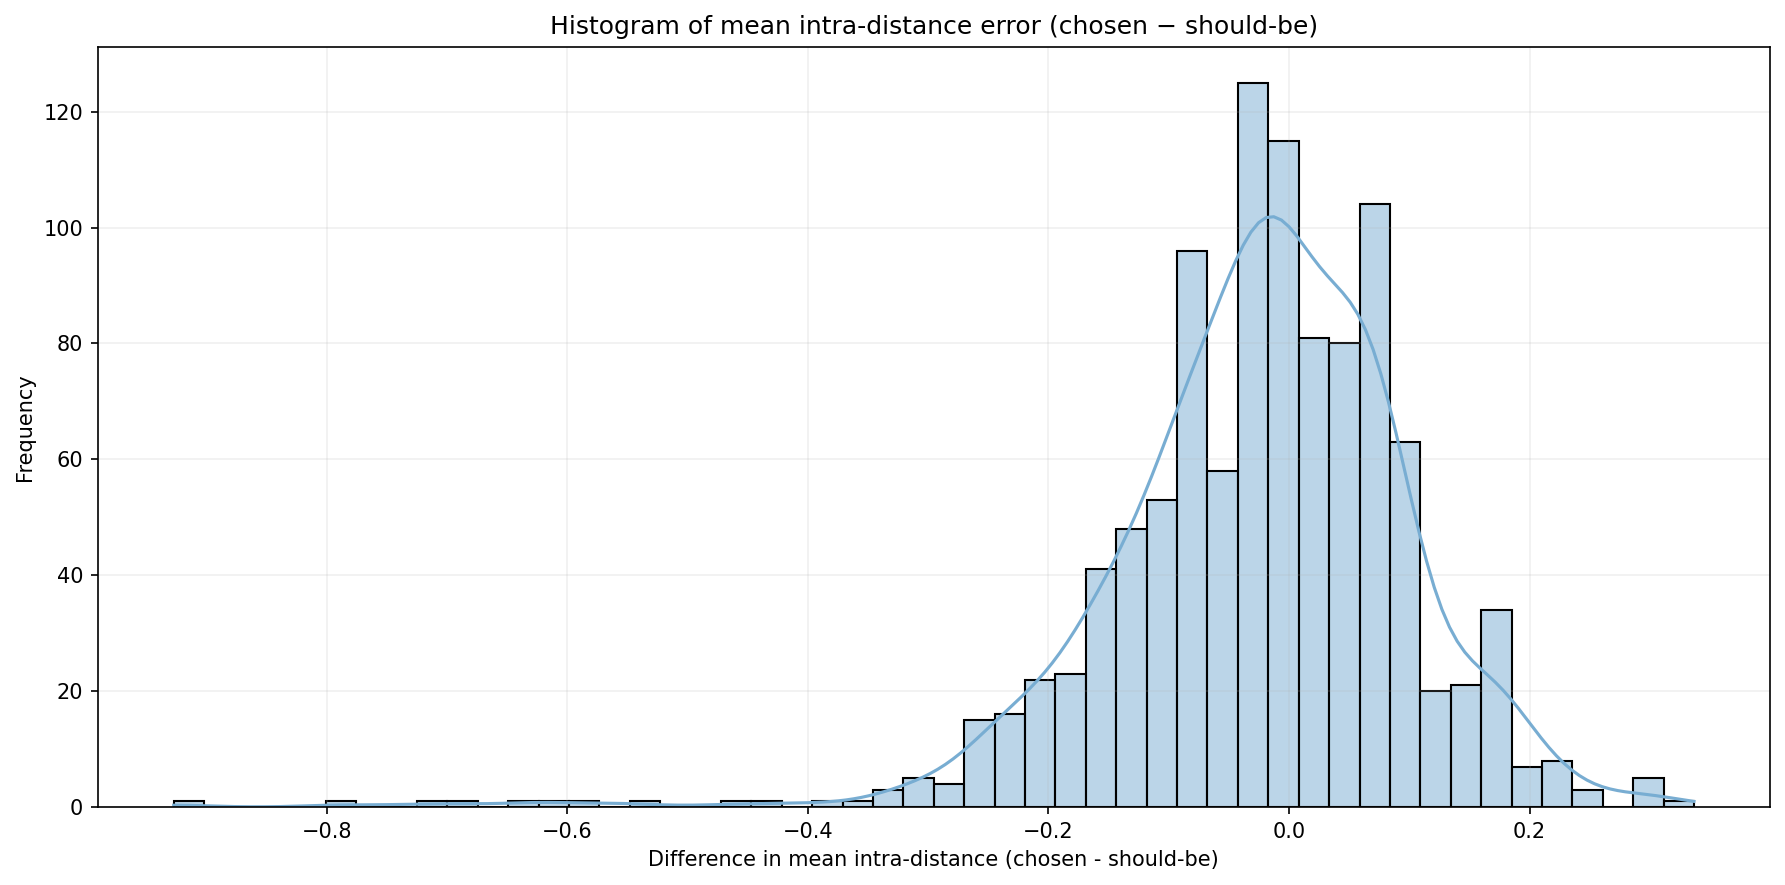

In [46]:
df_merged = df_incorrect_exp.merge(
        df_shouldbe_exp,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

df_merged["intra_dist_error"] = (df_merged["mean_intra_dist_diff_chosen"] - df_merged["mean_intra_dist_diff_shouldbe"])

plt.figure(figsize=(12, 6), dpi=150)
sns.histplot(df_merged["intra_dist_error"], bins=50, kde=True, color="#78add2")
plt.title("Histogram of mean intra-distance error (chosen − should-be)")
plt.xlabel("Difference in mean intra-distance (chosen - should-be)")
plt.ylabel("Frequency")
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

#### _Perform Welch’s t-test_

In [47]:
# One-sided 
group1 = df_incorrect_exp['mean_intra_dist_diff']     # incorrect chosen
group2 = df_shouldbe_exp['mean_intra_dist_diff']      # should-be chosen

t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='less')

print("\033[1mH1: incorrect < shouldbe\033[0m")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f} or {p_value:.2e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

H1: incorrect < shouldbe
t-statistic: -4.2876
p-value: 0.0000094817 or 9.48e-06
H0 can be rejected


### __Experiment 3 (with correction)__

In [48]:
def compute_track_behavior(df, df_AIS, stationary_threshold = 5):
    """
    Adds per-track behavior statistics to the given dataframe
    """
    df_AIS = df_AIS.copy()
    df_AIS["is_stationary"] = df_AIS["speed_kph"] < stationary_threshold
    track_behavior_stats = (
        df_AIS
        .groupby("ID")
        .agg(
            stationary_ratio = ("is_stationary", "mean")
        )
        .reset_index()
        .set_index("ID")
    )
    return df.merge(track_behavior_stats, left_on = "AIS_track_id", right_on = "ID", how = "left")

#### _Figure 1: Box plots of proportion of time stationary per group_

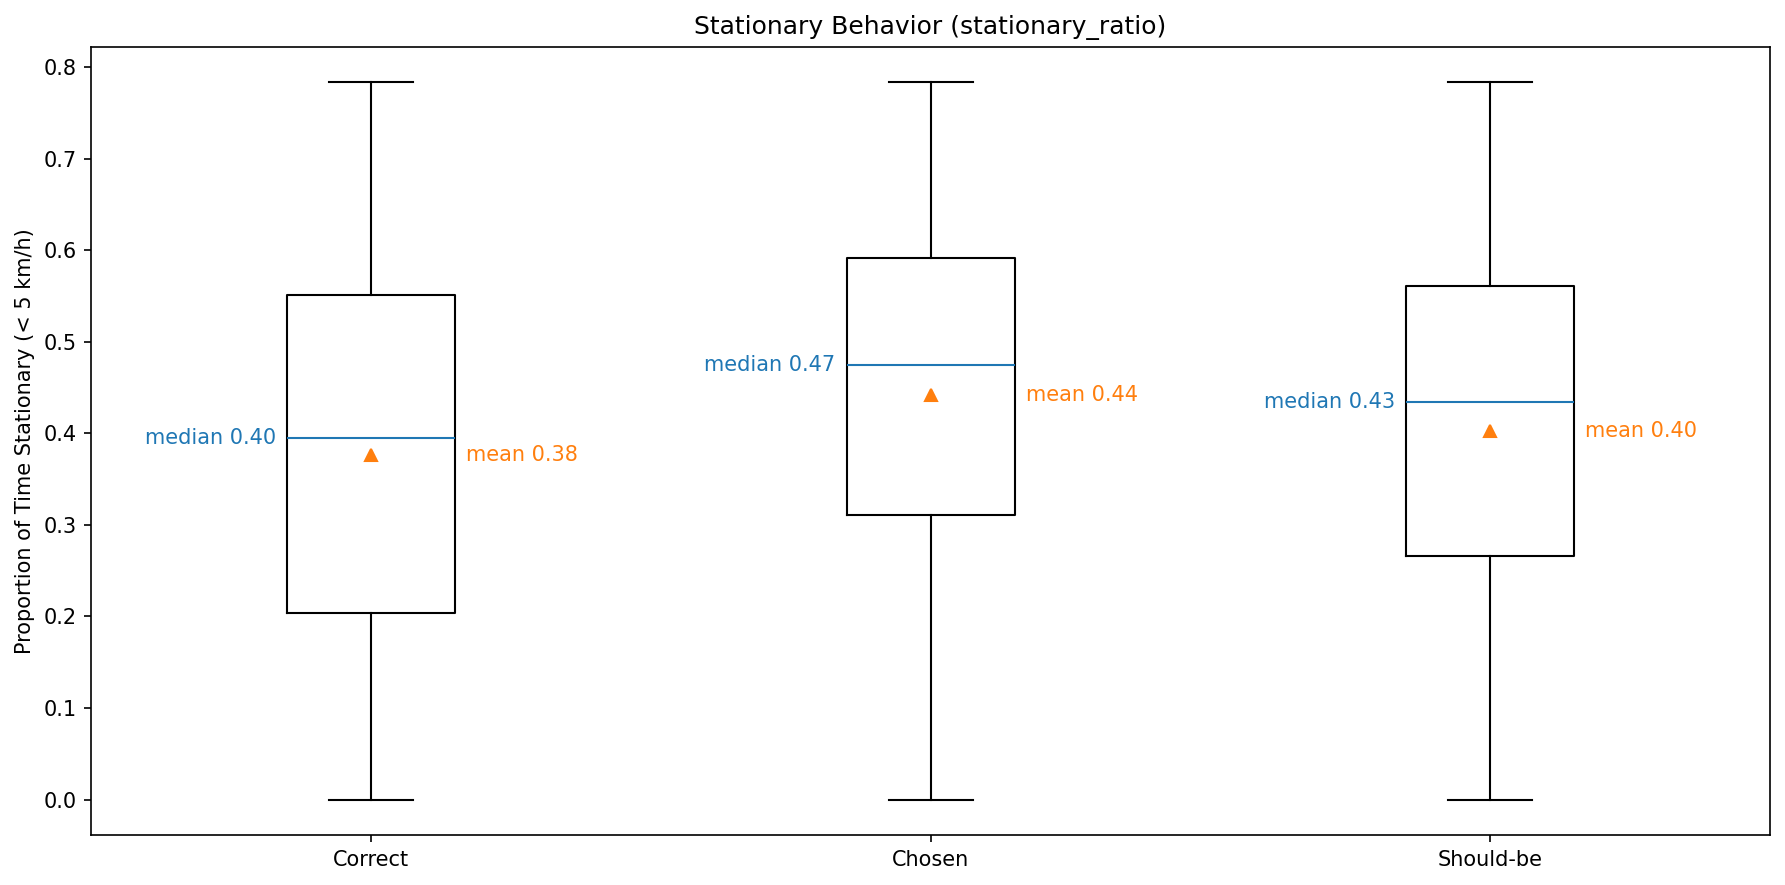

In [49]:
df_correct_exp = compute_track_behavior(df_correct_exp, df_AIS)
df_incorrect_exp = compute_track_behavior(df_incorrect_exp, df_AIS)
df_shouldbe_exp = compute_track_behavior(df_shouldbe_exp, df_AIS)

station_correct = df_correct_exp['stationary_ratio']
station_chosen  = df_incorrect_exp['stationary_ratio']
station_shouldbe = df_shouldbe_exp['stationary_ratio']

stationary_data = [station_correct, station_chosen, station_shouldbe]
labels = ['Correct', 'Chosen', 'Should-be']

station_means = [x.mean() for x in stationary_data]
station_medians = [x.median() for x in stationary_data]
meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')
medianprops = dict(color="tab:blue")

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
ax.boxplot(stationary_data, tick_labels=labels, showfliers=False, showmeans=True, medianprops=medianprops, meanprops=meanpointprops)
ax.set_title("Stationary Behavior (stationary_ratio)")
ax.set_ylabel("Proportion of Time Stationary (< 5 km/h)")

for i, (m, med) in enumerate(zip(station_means, station_medians), start=1):
    ax.text(i + 0.17, m,   f"mean {m:.2f}", color="tab:orange", ha='left', va='center')
    ax.text(i - 0.17, med, f"median {med:.2f}", color="tab:blue", ha='right', va='center')

plt.tight_layout()
plt.show()

#### _Figure 2: Difference in stationary ratio between chosen and should-be matches_

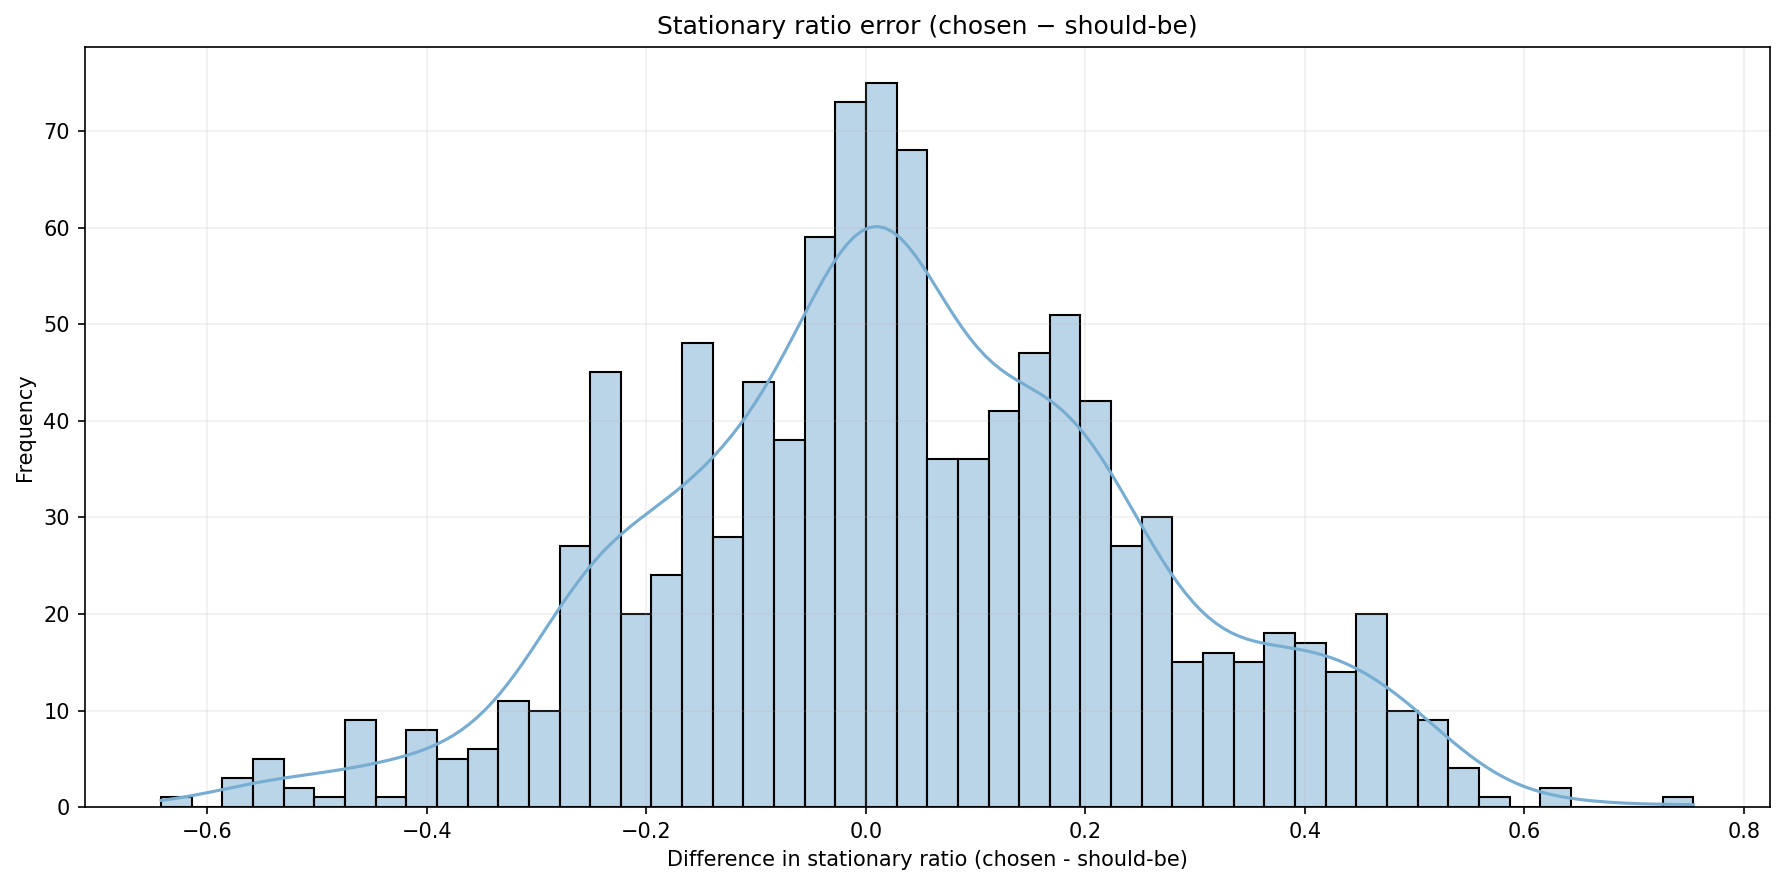

In [50]:
df_merged = df_incorrect_exp.merge(
        df_shouldbe_exp,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

df_merged["stationary_error"] = (df_merged["stationary_ratio_chosen"] - df_merged["stationary_ratio_shouldbe"])

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

sns.histplot(df_merged["stationary_error"], bins=50, kde=True, ax=ax, color="#78add2")
plt.title("Stationary ratio error (chosen − should-be)")
plt.xlabel("Difference in stationary ratio (chosen - should-be)")
plt.ylabel("Frequency")
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

#### _Perform Welch’s t-test_

In [51]:
# One-sided 
group1 = df_incorrect_exp['stationary_ratio']     # incorrect chosen
group2 = df_shouldbe_exp['stationary_ratio']      # should-be chosen

t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='greater')

print("\033[1mH1: incorrect > shouldbe\033[0m")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f} or {p_value:.2e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

H1: incorrect > shouldbe
t-statistic: 4.6646
p-value: 0.0000016420 or 1.64e-06
H0 can be rejected


### ___Point-level features___

Temporal and spatial difference between RF detections and their nearest AIS message

### __Experiment 4__

In [52]:
def compute_time_dist_diff(df_best, df_train):
    """
    For each best RF–AIS alignment, compute:
      - The closest AIS point in time
      - The time difference (in seconds)
      - The geographic distance difference (using haversine)

    Args:
        df_best (pd.DataFrame): DataFrame with best RF–AIS alignments.
        df_train (pd.DataFrame): Original training dataset containing RF and AIS data.

    Returns:
        pd.DataFrame: Merged DataFrame with extra columns for closest AIS timestamp, 
                      AIS coordinates, time difference, and distance difference.
    """

    # Extract all RF signals with their timestamps and coordinates
    df_RF = df_train[df_train["RF"].notna()].copy()
    df_RF = df_RF[["ID", "RF_Timestamp", "RF"]]
    # Assign a sequential ID to each RF signal within its track
    df_RF["RF_signal_id"] = df_RF.groupby("ID").cumcount() + 1

    # Merge the RF signals with the best alignments (df_best)
    df_merged = df_best.merge(
        df_RF.rename({"ID": "RF_track_id"}, axis=1),
        on=["RF_signal_id", "RF_track_id"],
        how="left"
    )

    # Extract all AIS signals (timestamps and coordinates)
    df_AIS = df_train[df_train["AIS"].notna()].copy()
    # Group AIS signals by track ID for fast lookup
    df_AIS_grouped = df_AIS.groupby("ID")

    # For each row, find the AIS point closest in time to the RF timestamp
    def compute_diffs(row):
        # Get all AIS points for this AIS track
        seq = df_AIS_grouped.get_group(row["AIS_track_id"])
        # Find the AIS point with minimum absolute time difference
        AIS_time, AIS_coords = min(
            zip(seq["AIS_Timestamp"], seq["AIS"]), 
            key=lambda x: abs(x[0] - row["RF_Timestamp"]).total_seconds()
        )
        # Compute absolute time difference (seconds)
        time_diff = abs((row["RF_Timestamp"] - AIS_time).total_seconds())
        # Compute spatial distance using haversine
        distance_diff = haversine(row["RF"], AIS_coords)
            
        return pd.Series({
            "AIS_Timestamp": AIS_time,
            "AIS": AIS_coords,
            "time_diff": time_diff, 
            "distance_diff": distance_diff
        })
        
    # Columns to add to df_merged
    cols = ["AIS_Timestamp", "AIS", "time_diff", "distance_diff"]
        
    # Apply the compute_diff function to each row
    df_merged[cols] = df_merged.apply(compute_diffs, axis=1)
    
    return df_merged

In [53]:
df_correct_exp = compute_time_dist_diff(df_correct_exp, df_train_set)
df_incorrect_exp = compute_time_dist_diff(df_incorrect_exp, df_train_set)
df_shouldbe_exp = compute_time_dist_diff(df_shouldbe_exp, df_train_set)

#### _Figure 1: Box plots of temporal separation AIS-RF pair per group_

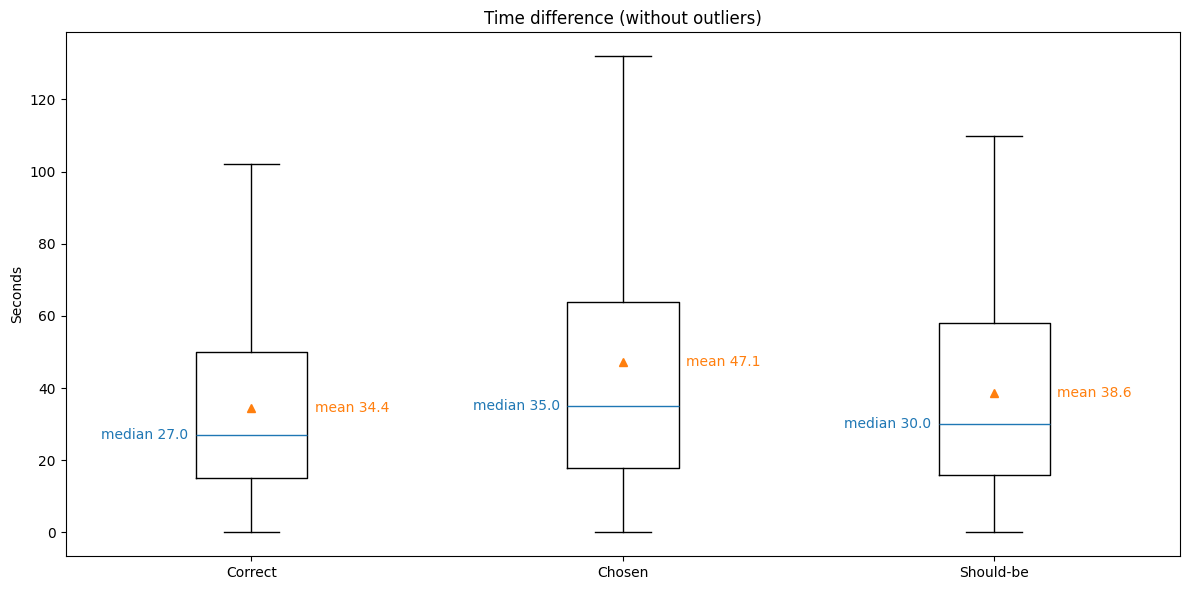

In [54]:
time_correct = df_correct_exp['time_diff']
time_chosen = df_incorrect_exp['time_diff']
time_shouldbe = df_shouldbe_exp['time_diff']

data_time = [time_correct, time_chosen, time_shouldbe]

labels = ['Correct', 'Chosen', 'Should-be']

mean_time = [x.mean() for x in data_time]
med_time = [x.median() for x in data_time]
meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')
medianprops = dict(color="tab:blue")

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(data_time, tick_labels=labels, showfliers=False, showmeans=True, medianprops=medianprops, meanprops=meanpointprops)
ax.set_title('Time difference (without outliers)')
ax.set_ylabel('Seconds')
for i, (mean, median) in enumerate(zip(mean_time, med_time), start=1):
    ax.text(i + 0.17, mean, f"mean {mean:.1f}", color='tab:orange', ha='left', va='center')
    ax.text(i - 0.17, median, f"median {median:.1f}", color='tab:blue', ha='right', va='center')

plt.tight_layout()
plt.show()

#### _Figure 2: Difference in temporal separation AIS-RF pair between chosen and should-be matches_

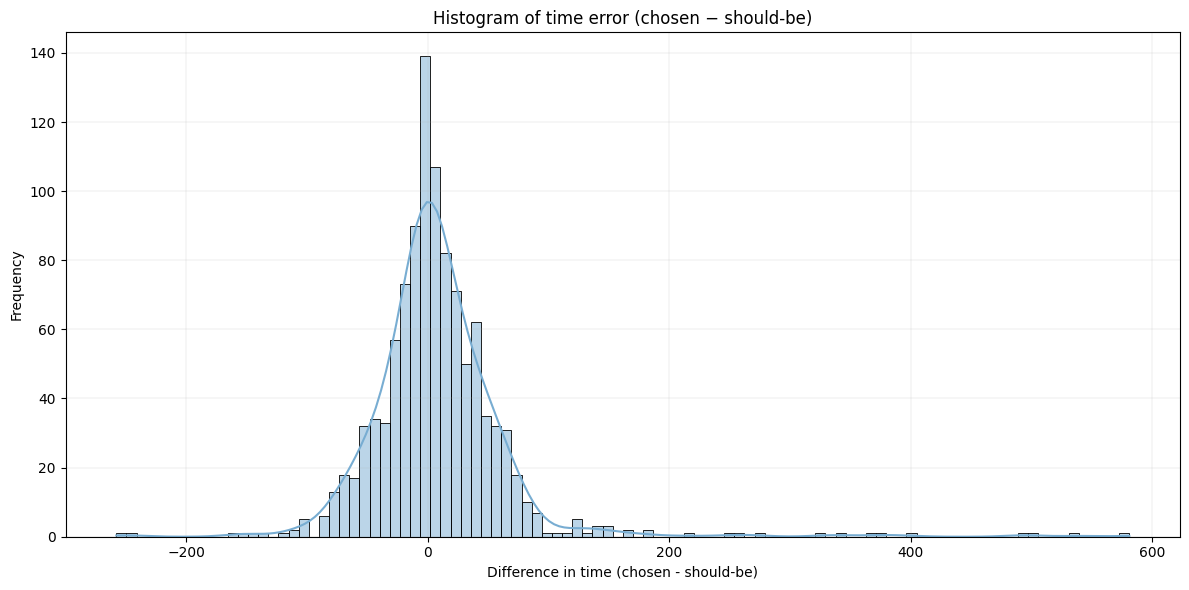

In [55]:
df_merged = df_incorrect_exp.merge(
        df_shouldbe_exp,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

df_merged["time_error"] = df_merged["time_diff_chosen"] - df_merged["time_diff_shouldbe"]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df_merged["time_error"], bins=100, kde=True, ax=ax, color="#78add2")
ax.set_title("Histogram of time error (chosen − should-be)")
ax.set_xlabel("Difference in time (chosen - should-be)")
ax.set_ylabel("Frequency")
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

#### _Perform paired t-test_

In [56]:
# One-sided 
group1 = df_incorrect_exp["time_diff"]  # incorrect chosen
group2 = df_shouldbe_exp["time_diff"]   # should-be chosen

res = ttest_rel(group1, group2, alternative="less")
t_stat = res.statistic
p_value = res.pvalue

print("\033[1mH1: incorrect < shouldbe\033[0m")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f} or {p_value:.2e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

H1: incorrect < shouldbe
t-statistic: 4.6016
p-value: 0.9999976510 or 1.00e+00
H0 cannot be rejected


In [57]:
# Two-sided 
group1 = df_incorrect_exp["time_diff"]  # incorrect chosen
group2 = df_shouldbe_exp["time_diff"]   # should-be chosen

res = ttest_rel(group1, group2, alternative="two-sided")
t_stat = res.statistic
p_value = res.pvalue

print("\033[1mH1: incorrect < shouldbe\033[0m")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f} or {p_value:.2e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

H1: incorrect < shouldbe
t-statistic: 4.6016
p-value: 0.0000046980 or 4.70e-06
H0 can be rejected


#### _Figure 1: Box plots of spatial separation AIS-RF pair per group_

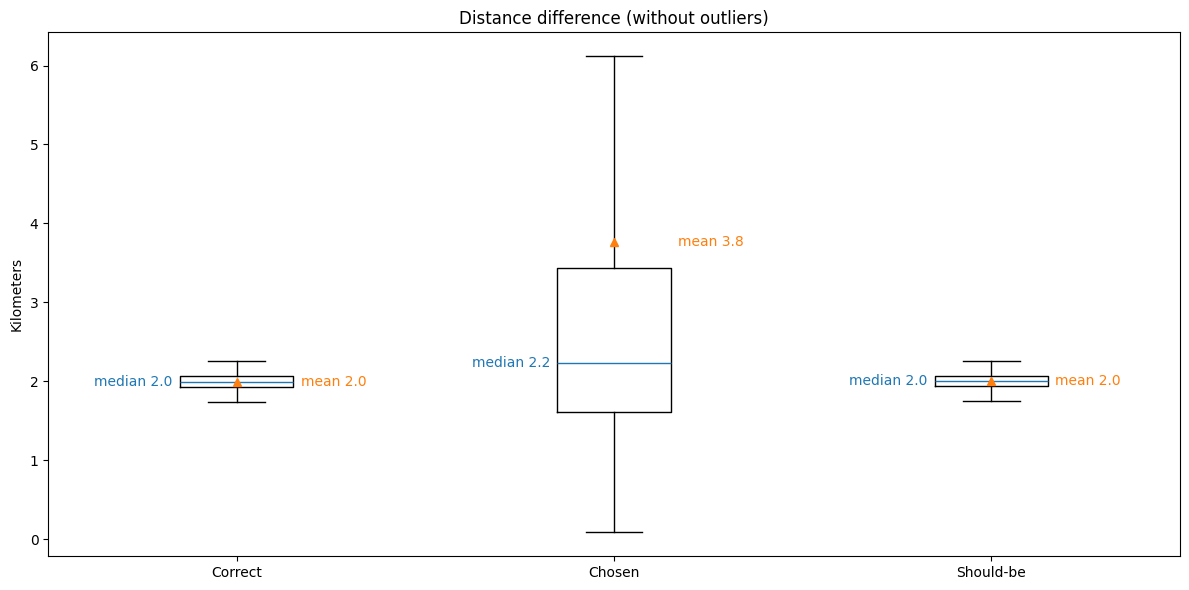

In [58]:
dist_correct = df_correct_exp['distance_diff']
dist_chosen = df_incorrect_exp['distance_diff']
dist_shouldbe = df_shouldbe_exp['distance_diff']

data_dist = [dist_correct, dist_chosen, dist_shouldbe]
labels = ['Correct', 'Chosen', 'Should-be']

mean_dist = [x.mean() for x in data_dist]
med_dist = [x.median() for x in data_dist]
meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')
medianprops = dict(color="tab:blue")

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(data_dist, tick_labels=labels, showfliers=False, showmeans=True, medianprops=medianprops, meanprops=meanpointprops)
ax.set_title('Distance difference (without outliers)')
ax.set_ylabel('Kilometers')
for i, (mean, median) in enumerate(zip(mean_dist, med_dist), start=1):
    ax.text(i + 0.17, mean, f"mean {mean:.1f}", color='tab:orange', ha='left', va='center')
    ax.text(i - 0.17, median, f"median {median:.1f}", color='tab:blue', ha='right', va='center')

plt.tight_layout()
plt.show()

#### _Figure 2: Difference in temporal separation AIS-RF pair between chosen and should-be matches_

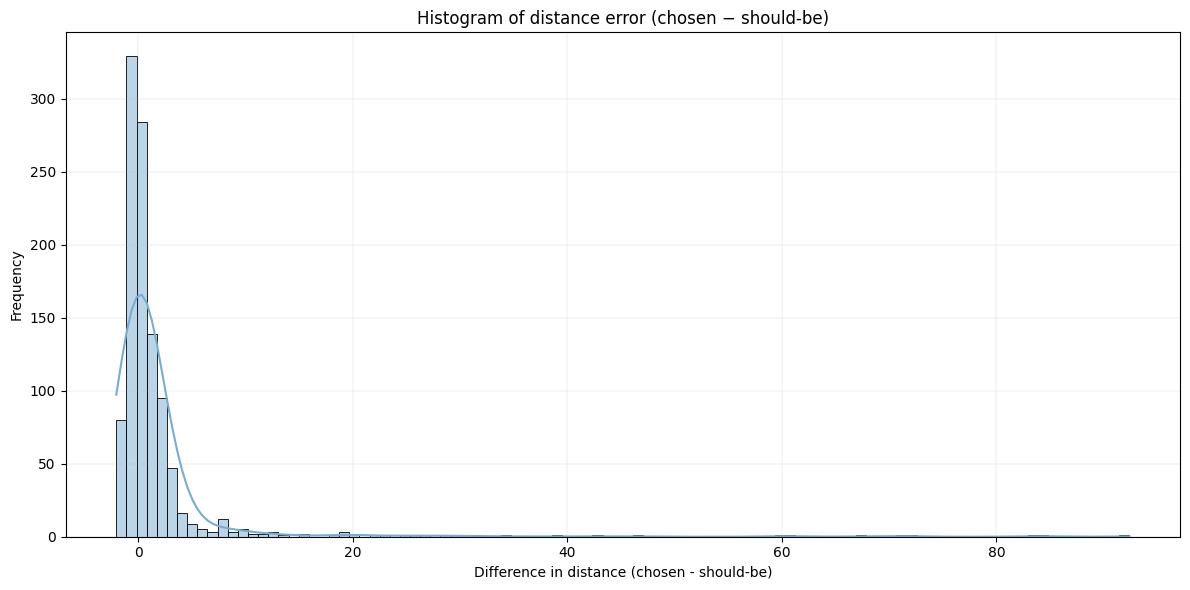

In [59]:
df_merged = df_incorrect_exp.merge(
        df_shouldbe_exp,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

df_merged["distance_error"] = df_merged["distance_diff_chosen"] - df_merged["distance_diff_shouldbe"]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df_merged["distance_error"], bins=100, kde=True, ax=ax, color="#78add2")
ax.set_title("Histogram of distance error (chosen − should-be)")
ax.set_xlabel("Difference in distance (chosen - should-be)")
ax.set_ylabel("Frequency")
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

#### _Perform paired t-test_

In [60]:
# One-sided 
group1 = df_incorrect_exp["distance_diff"]  # incorrect chosen
group2 = df_shouldbe_exp["distance_diff"]   # should-be chosen

res = ttest_rel(group1, group2, alternative="less")
t_stat = res.statistic
p_value = res.pvalue

print("\033[1mH1: incorrect < shouldbe\033[0m")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f} or {p_value:.2e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

H1: incorrect < shouldbe
t-statistic: 7.5566
p-value: 1.0000000000 or 1.00e+00
H0 cannot be rejected


In [61]:
# Two-sided 
group1 = df_incorrect_exp["distance_diff"]  # incorrect chosen
group2 = df_shouldbe_exp["distance_diff"]   # should-be chosen

res = ttest_rel(group1, group2, alternative="two-sided")
t_stat = res.statistic
p_value = res.pvalue

print("\033[1mH1: incorrect < shouldbe\033[0m")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f} or {p_value:.2e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

H1: incorrect < shouldbe
t-statistic: 7.5566
p-value: 0.0000000000 or 8.91e-14
H0 can be rejected


### __Incorrect Chosen Matches__

In [62]:
# Distance/time differences: (incorrect - should-be)
dist_diff = df_incorrect_exp['distance_diff'] - df_shouldbe_exp['distance_diff']
time_diff = df_incorrect_exp['time_diff'] - df_shouldbe_exp['time_diff']

# Quick counts of which side is larger (>, <, == 0)
print("Distance diffs(>0, <0, ==0):",
      np.sum(dist_diff > 0), np.sum(dist_diff < 0), np.sum(dist_diff == 0))
print("Time diffs(>0, <0, ==0):",
      np.sum(time_diff > 0), np.sum(time_diff < 0), np.sum(time_diff == 0))

Distance diffs(>0, <0, ==0): 614 448 1
Time diffs(>0, <0, ==0): 573 476 14


In [63]:
time_neg = time_diff < 0
dist_neg = dist_diff < 0

both_neg = np.sum(time_neg & dist_neg) # Both time and distance differences are negative
time_only_neg = np.sum(time_neg & ~dist_neg) # Only time difference is negative
dist_only_neg = np.sum(~time_neg & dist_neg) # Only distance difference is negative
rest = np.sum(~time_neg & ~dist_neg) # Neither time nor distance differences are negative

# Percentages
total = len(time_diff)
both_neg_pct = 100 * both_neg / total
time_only_neg_pct = 100 * time_only_neg / total
dist_only_neg_pct = 100 * dist_only_neg / total
rest_pct = 100 * rest / total

print("Percentages (of all pairs):")
print(f"both: {both_neg_pct:.2f}%")
print(f"only time: {time_only_neg_pct:.2f}%")
print(f"only distance: {dist_only_neg_pct:.2f}%")
print(f"rest: {rest_pct:.2f}%")

Percentages (of all pairs):
both: 20.23%
only time: 24.55%
only distance: 21.92%
rest: 33.30%


In [64]:
# Merge to get all preselected pairs that have forward results
df_all_scores_preselected = df_preselection_multimatch.merge(df_all_forward_results, how="inner")

# Enrich with nearest AIS time/distance metrics
df_all_scores_preselected = compute_time_dist_diff(df_all_scores_preselected, df_train_set)

# Compute AIS–RF probability score for each row
# The AIS–RF probability was chosen to avoid the fixed match-probability thresholds of 2 km and 120 seconds
AIS_RF_scores = []
for index, row in df_all_scores_preselected.iterrows():
    AIS_RF_scores.append(AIS_RF_probability(row['time_diff'],row['distance_diff']))
df_all_scores_preselected['AIS_RF_score'] = AIS_RF_scores

# For each (RF_signal_id, RF_track_id) pair, mark True for the AIS track
# with the highest AIS–RF probability score, False otherwise
df_all_scores_preselected['is_match_ref'] = (
    df_all_scores_preselected["AIS_RF_score"].eq(
        df_all_scores_preselected.groupby(["RF_signal_id", "RF_track_id"])["AIS_RF_score"].transform('max')))

# Keep only rows that are in the validation set
df_all_scores_preselected = df_all_scores_preselected.merge(df_experiments)

metrics_ref, chosen_ref, all_tracks_ref = correct_forward_score(
    df_all_scores_preselected, df_AIS_stats, best[0], match_col="is_match_ref"
)

In [65]:
for key, value in metrics_ref.items():
    print(f"{key}: {value}")

precision: 0.7898
recall: 0.7898
f1_score: 0.7898
accuracy: 0.8414
TP: 3851
FP: 1025
FN: 1025
TN: 7027


In [66]:
# Split results again into three dataframes (correct, incorrect, should-be matches)
best_chosen_ref = chosen_ref[chosen_ref['chosen']].reset_index(drop=True)

df_correct_ref  = best_chosen_ref[best_chosen_ref["is_match_ref"]].sort_values(
    ["RF_signal_id", "RF_track_id"]).reset_index(drop=True)
df_incorrect_ref= best_chosen_ref[~best_chosen_ref["is_match_ref"]].sort_values(
    ["RF_signal_id", "RF_track_id"]).reset_index(drop=True)
df_shouldbe_ref = (
    all_tracks_ref[all_tracks_ref["is_match_ref"]]
      .merge(df_incorrect_ref[["RF_signal_id", "RF_track_id"]], 
             on=["RF_signal_id", "RF_track_id"], how="inner").sort_values(
                 ["RF_signal_id", "RF_track_id"]).reset_index(drop=True)
)

# Original and reference dataframes for comparison
original = pd.concat([
    df_correct_exp[['RF_track_id', 'RF_signal_id']].assign(label_original='correct'),
    df_incorrect_exp[['RF_track_id', 'RF_signal_id']].assign(label_original='incorrect'),
    df_shouldbe_exp[['RF_track_id', 'RF_signal_id']].assign(label_original='should_be'),], 
                     ignore_index=True).drop_duplicates(['RF_track_id', 'RF_signal_id'])

reference = pd.concat([
    df_correct_ref[['RF_track_id', 'RF_signal_id']].assign(label_reference='correct'),
    df_incorrect_ref[['RF_track_id', 'RF_signal_id']].assign(label_reference='incorrect'),
    df_shouldbe_ref[['RF_track_id', 'RF_signal_id']].assign(label_reference='should_be'),], 
                      ignore_index=True).drop_duplicates(['RF_track_id', 'RF_signal_id'])

# Transition matrix (orig → new)
original_reference_df = (original.merge(
    reference, 
    on=["RF_signal_id", "RF_track_id"], 
    how='outer', indicator=True).fillna({'label_original': '<missing>', 'label_reference': '<missing>'}))
transition = pd.crosstab(original_reference_df['label_original'], original_reference_df['label_reference'], dropna=False)
print("Transition matrix (generated → nearest):")
print(transition)

# Which events changed label category?
changed = original_reference_df[original_reference_df['label_original'] != original_reference_df['label_reference']].copy()
changed['transition'] = changed['label_original'] + ' → ' + changed['label_reference']
print("\nTop transitions:")
print(changed['transition'].value_counts())

Transition matrix (generated → nearest):
label_reference  correct  incorrect
label_original                     
correct             3456        357
incorrect            395        668

Top transitions:
transition
incorrect → correct    395
correct → incorrect    357
Name: count, dtype: int64
